In [63]:
import sqlite3
from rosidl_runtime_py.utilities import get_message
from rclpy.serialization import deserialize_message
import csv
import yaml
from read_bag import *

import matplotlib as mpl
import matplotlib.pyplot as plt 


In [64]:


# path to the bagfile
bag_file = '/home/toffanetto/vilma/bags/2025-10-15_throttle_identification/rosbag2_2025_10_15-14_37_09-linear20-09/rosbag2_2025_10_15-14_37_09_0.db3'

# topic name
topic_name = '/vilma_ma_debug/sensors_ma'
sensors_ma = []

### connect to the database
conn, c = connect(bag_file)

### get all topics names and types
topic_names = getAllTopicsNames(c, print_out=False)
topic_types = getAllMsgsTypes(c, print_out=False)

# Create a map for quicker lookup
type_map = {topic_names[i]:topic_types[i] for i in range(len(topic_types))}

### get all timestamps and all messages
t, msgs = getAllMessagesInTopic(c, topic_name, print_out=True)

# Deserialize the message
msg_type = get_message(type_map[topic_name])  # Assuming type_map is a dictionary mapping topic names to message types
        
for timestamp, message in zip(t, msgs):
        deserialized_msg = deserialize_message(message, msg_type)
        sensors_ma.append(deserialized_msg)
                

topic_name = '/vilma_ma_debug/state_ma'
state_ma = []

### connect to the database
conn, c = connect(bag_file)

### get all topics names and types
topic_names = getAllTopicsNames(c, print_out=False)
topic_types = getAllMsgsTypes(c, print_out=False)

# Create a map for quicker lookup
type_map = {topic_names[i]:topic_types[i] for i in range(len(topic_types))}

### get all timestamps and all messages
t, msgs = getAllMessagesInTopic(c, topic_name, print_out=True)

# Deserialize the message
msg_type = get_message(type_map[topic_name])  # Assuming type_map is a dictionary mapping topic names to message types
        
for timestamp, message in zip(t, msgs):
        deserialized_msg = deserialize_message(message, msg_type)
        state_ma.append(deserialized_msg)
        
### close connection to the database
close(conn)


There are  1440 messages in  /vilma_ma_debug/sensors_ma

There are  1441 messages in  /vilma_ma_debug/state_ma


In [65]:
throttle = []
speed = []
user_braking = []
t = []
for i in range(len(sensors_ma)):
    throttle.append(sensors_ma[i].data[8])
    speed.append(state_ma[i].data[11])
    user_braking.append(sensors_ma[i].data[27])
    t.append(state_ma[i].data[1])

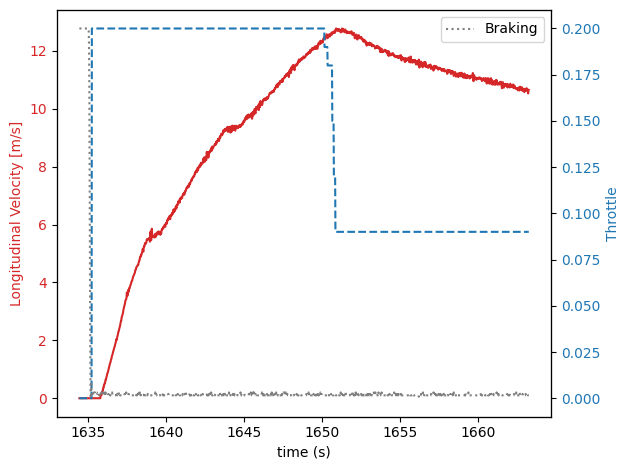

In [67]:
fig, ax1 = plt.subplots()

# plt.title('15% throttle step')

color = 'tab:red'
ax1.set_xlabel('time (s)')
ax1.set_ylabel('Longitudinal Velocity [m/s]', color=color)
ax1.plot(t, speed, color=color, label='Speed')
ax1.tick_params(axis='y', labelcolor=color)
# ax1.set_xlim(1011, 1021)  # Set x-axis limits
# ax1.set_ylim(0, 5) # Set y-axis limits

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('Throttle', color=color)  # we already handled the x-label with ax1
ax2.plot(t, throttle, color=color, linestyle='--', label='Throttle')
ax2.tick_params(axis='y', labelcolor=color)
# ax2.set_xlim(1011, 1021)  # Set x-axis limits
# ax2.set_ylim(0, 0.2) # Set y-axis limits

ax3 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = 'tab:gray'
ax3.set_ylabel('', color=color)  # we already handled the x-label with ax1
ax3.plot(t, user_braking, color=color, linestyle=':', label='Braking')
ax3.tick_params(axis='y', labelcolor=color)
ax3.set_yticks([])
ax3.set_yticks([], minor=True)
# ax3.set_xlim(1011, 1021)  # Set x-axis limits
# ax3.set_ylim(0) # Set y-axis limits

plt.legend()

fig.tight_layout()  # otherwise the right y-label is slightly clipped

plt.savefig('lin20.pdf') 

plt.show()

